<a href="https://colab.research.google.com/github/Ashritha0848/NLP_Assignments/blob/main/Assignment_11_2%2CBatch_9%2C2403A52229%2CNLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset:

                                   review  sentiment
0  This movie is fantastic and I loved it          1
1                        Worst movie ever          0
2          Amazing acting and great story          1
3                        I hate this film          0
4                  Best movie of the year          1
5      Terrible direction and boring plot          0
6                Loved the cinematography          1
7                         Not good at all          0
8         Excellent performance by actors          1
9                           Waste of time          0

Processed Text:

                                   review  \
0  This movie is fantastic and I loved it   
1                        Worst movie ever   
2          Amazing acting and great story   
3                        I hate this film   
4                  Best movie of the year   
5      Terrible direction and boring plot   
6                Loved the cinematography   
7                   

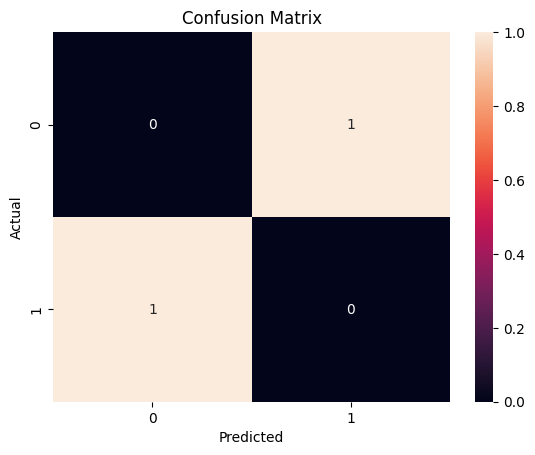

In [1]:
# STEP 1: Import Libraries
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 2: Create Sample Movie Review Dataset
data = {
    "review":[
        "This movie is fantastic and I loved it",
        "Worst movie ever",
        "Amazing acting and great story",
        "I hate this film",
        "Best movie of the year",
        "Terrible direction and boring plot",
        "Loved the cinematography",
        "Not good at all",
        "Excellent performance by actors",
        "Waste of time"
    ],
    "sentiment":[1,0,1,0,1,0,1,0,1,0]   # 1 = Positive, 0 = Negative
}

df = pd.DataFrame(data)

print("Original Dataset:\n")
print(df)

# STEP 3: Text Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    return text

df['clean_review'] = df['review'].apply(clean_text)

print("\nProcessed Text:\n")
print(df[['review','clean_review']])

# STEP 4: TF-IDF Feature Extraction
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

print("\nVocabulary Size:", len(vectorizer.vocabulary_))

# STEP 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# STEP 6: Train Logistic Regression Model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# STEP 7: Predictions
y_pred = model.predict(X_test)

# STEP 8: Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()